In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Optional: make plots a bit larger
plt.rcParams["figure.figsize"] = (8, 5)


In [4]:
data_dir = Path("./visualization")  # or Path("/path/to/your/csvs")

stations_path = data_dir / "station_ids.csv"
stats_path = data_dir / "station_statistics.csv"  # name from previous script

stations_df = pd.read_csv(stations_path)
stats_df = pd.read_csv(stats_path)

print("Stations shape:", stations_df.shape)
print("Stats shape:", stats_df.shape)

stations_df.head(), stats_df.head()


Stations shape: (136, 5)
Stats shape: (129, 5)


(                             station_id                            name  \
 0  916c48da-19f6-4af4-80f3-8bf0abef02c7                  Landsitz Lotte   
 1  7ae3c569-ca32-43d7-883f-6280c1eefa89                        Birdview   
 2  9ab25c4c-232d-48ab-8f79-97b2d36ba454                      Ententeich   
 3  987fe29d-45a9-4214-904f-b358210b37da                      Merschkamp   
 4  62e67d48-9a0b-4f9f-a6be-4547c2e2f5bd  Gladbeck International Airport   
 
          lat       lng          last_movement_date  
 0  52.256338  7.905350  2025-11-09 10:04:41.809555  
 1  52.043959  7.853615  2022-06-18 18:35:07.665951  
 2  52.144603  7.961177  2023-05-28 17:13:05.966735  
 3  51.957510  7.665560  2024-06-04 08:09:31.948091  
 4  51.597074  6.980493  2025-01-09 12:45:59.306031  ,
                              station_id  numberOfMovements  \
 0  916c48da-19f6-4af4-80f3-8bf0abef02c7              38070   
 1  7ae3c569-ca32-43d7-883f-6280c1eefa89               2534   
 2  9ab25c4c-232d-48ab-8f79-

In [5]:
# Inner join: keep only stations that have statistics
merged = pd.merge(
    stations_df,
    stats_df,
    on="station_id",
    how="inner",
    suffixes=("_meta", "_stats"),
)

print("Merged shape:", merged.shape)
merged[["station_id", "name", "numberOfMovements"]].head()


Merged shape: (129, 9)


,station_id,name,numberOfMovements
0,916c48da-19f6-4af4-80f3-8bf0abef02c7,Landsitz Lotte,38070
1,7ae3c569-ca32-43d7-883f-6280c1eefa89,Birdview,2534
2,9ab25c4c-232d-48ab-8f79-97b2d36ba454,Ententeich,13549
3,987fe29d-45a9-4214-904f-b358210b37da,Merschkamp,9520
4,62e67d48-9a0b-4f9f-a6be-4547c2e2f5bd,Gladbeck International Airport,94182


In [6]:
# Inner join: keep only stations that have statistics
merged = pd.merge(
    stations_df,
    stats_df,
    on="station_id",
    how="inner",
    suffixes=("_meta", "_stats"),
)

print("Merged shape:", merged.shape)
merged[["station_id", "name", "numberOfMovements"]].head()


Merged shape: (129, 9)


,station_id,name,numberOfMovements
0,916c48da-19f6-4af4-80f3-8bf0abef02c7,Landsitz Lotte,38070
1,7ae3c569-ca32-43d7-883f-6280c1eefa89,Birdview,2534
2,9ab25c4c-232d-48ab-8f79-97b2d36ba454,Ententeich,13549
3,987fe29d-45a9-4214-904f-b358210b37da,Merschkamp,9520
4,62e67d48-9a0b-4f9f-a6be-4547c2e2f5bd,Gladbeck International Airport,94182


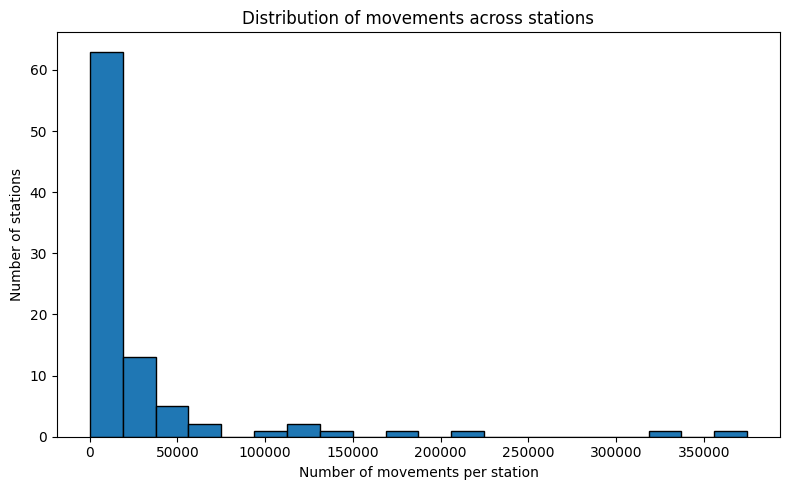

|     | station_id                           | name                                        |     lat |       lng | last_movement_date         |   numberOfMovements |   numberOfDetections |   numberOfValidatedBirds | validatedBirds                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | movements_bin    |   validation_rate |
|----:|:-------

In [141]:
# Filter out stations with 0 movements
filtered = merged[merged["numberOfMovements"] > 0]

# Plot histogram
ax = filtered["numberOfMovements"].plot.hist(
    bins=20,
    edgecolor="black"
)
ax.set_xlabel("Number of movements per station")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of movements across stations")
plt.tight_layout()
plt.show()


print(merged.to_markdown())

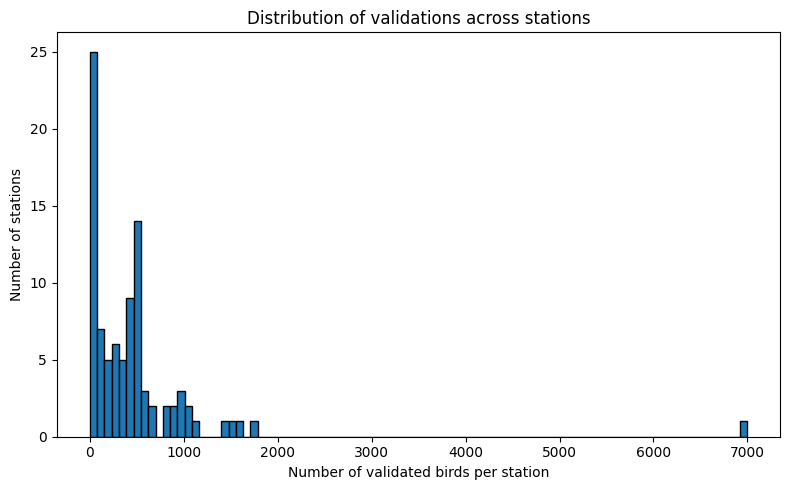

In [86]:
# Plot histogram
ax = filtered["numberOfValidatedBirds"].plot.hist(
    bins=90,
    edgecolor="black"
)
ax.set_xlabel("Number of validated birds per station")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of validations across stations")
plt.tight_layout()
plt.show()


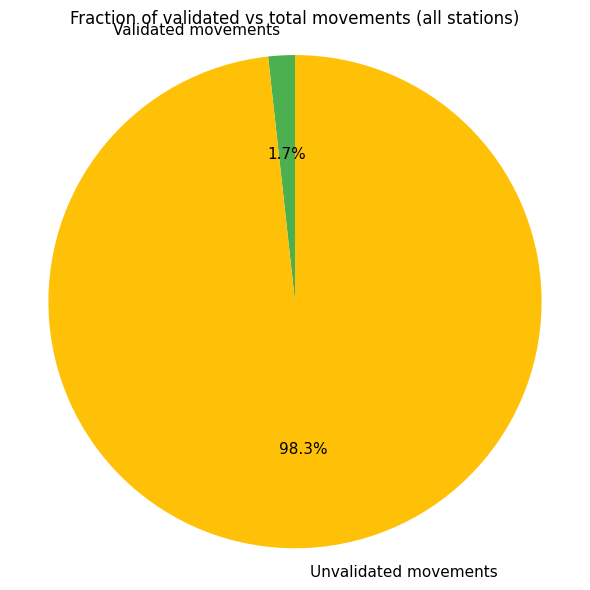

Total movements: 2,442,891
Validated movements: 42,542 (1.74%)


In [74]:
# Calculate global sums
total_movements = merged["numberOfMovements"].sum()
total_validated = merged["numberOfValidatedBirds"].sum()

# Derive the remainder (non-validated movements)
non_validated = total_movements - total_validated
if non_validated < 0:
    non_validated = 0  # safety clamp if any inconsistency

# Prepare data for pie chart
labels = ["Validated movements", "Unvalidated movements"]
sizes = [total_validated, non_validated]
colors = ["#4CAF50", "#FFC107"]

# Plot pie chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 11}
)
ax.set_title("Fraction of validated vs total movements (all stations)")
ax.axis("equal")  # ensures circle shape
plt.tight_layout()
plt.show()

print(f"Total movements: {total_movements:,}")
print(f"Validated movements: {total_validated:,} ({100*total_validated/total_movements:.2f}%)")


C:\Users\annik\AppData\Local\Temp\ipykernel_1224\3458719282.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(species_df["latinName"], rotation=60, ha="right")


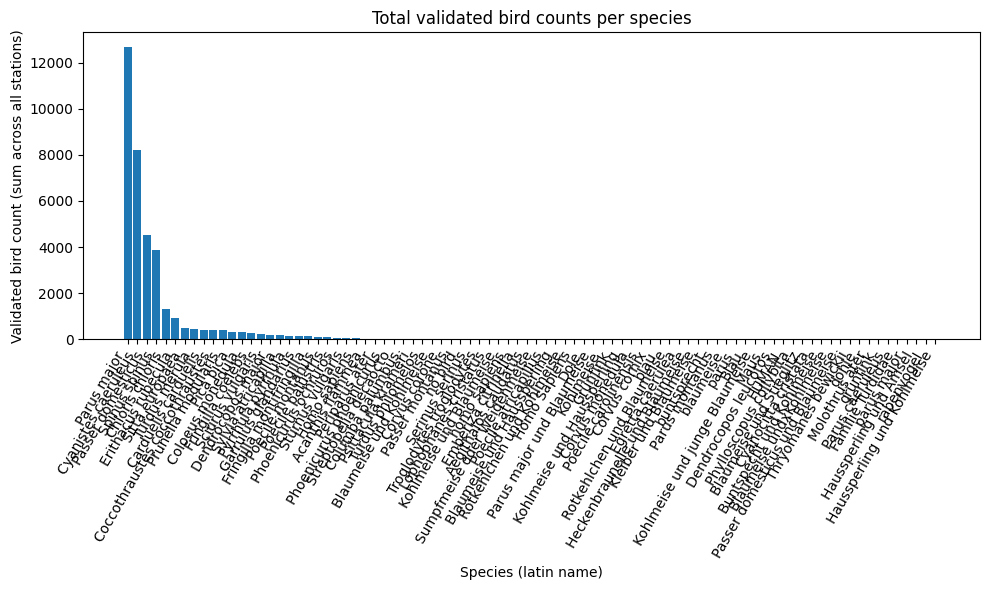

|    | latinName                       |   count |
|---:|:--------------------------------|--------:|
|  0 | Parus major                     |   12679 |
|  2 | Cyanistes caeruleus             |    8226 |
|  1 | Passer domesticus               |    4514 |
| 27 | Spinus spinus                   |    3884 |
| 15 | Chloris chloris                 |    1295 |
|  3 | Erithacus rubecula              |     917 |
| 21 | Sitta europaea                  |     504 |
|  5 | Turdus merula                   |     444 |
| 23 | Carduelis carduelis             |     401 |
|  4 | Coccothraustes coccothraustes   |     392 |
| 18 | Prunella modularis              |     385 |
| 19 | Pica pica                       |     316 |
| 22 | Coloeus monedula                |     305 |
| 16 | Fringilla coelebs               |     257 |
| 31 | Sciurus vulgaris                |     243 |
| 11 | Dendrocopos major               |     186 |
| 13 | Sylvia atricapilla              |     185 |
| 25 | Pyrrhula pyrrhula       

In [98]:

from collections import Counter

species_counter = Counter()

# Iterate through each station's validatedBirds column
for entry in merged["validatedBirds"].dropna():
    # Extract tuples of form (species, number)
    matches = re.findall(r"\(([^,]+),\s*([0-9]+)\)", entry)
    for latin_name, count in matches:
        latin_name = latin_name.strip()
        if latin_name and latin_name.lower() not in ["", "none"]:
            species_counter[latin_name] += int(count)

# Convert to DataFrame
species_df = pd.DataFrame(
    species_counter.items(), columns=["latinName", "count"]
).sort_values("count", ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(species_df["latinName"], species_df["count"])
ax.set_xticklabels(species_df["latinName"], rotation=60, ha="right")
ax.set_xlabel("Species (latin name)")
ax.set_ylabel("Validated bird count (sum across all stations)")
ax.set_title("Total validated bird counts per species")
plt.tight_layout()
plt.show()

print(species_df.to_markdown())

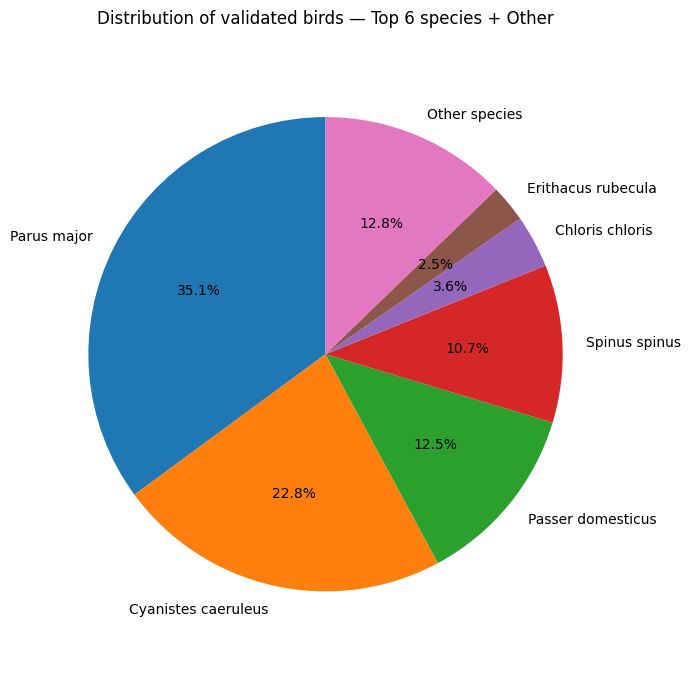

,latinName,count
0,Parus major,12679
2,Cyanistes caeruleus,8226
1,Passer domesticus,4514
27,Spinus spinus,3884
15,Chloris chloris,1295
3,Erithacus rubecula,917
6,Other species,4617


In [93]:
# Choose how many top species to show individually
top_k = 6

# Compute top K + remainder
top_df = species_df.head(top_k)
other_sum = species_df["count"].iloc[top_k:].sum()

# Build combined dataframe for pie
pie_df = top_df.copy()
if other_sum > 0:
    pie_df.loc[len(pie_df)] = ["Other species", other_sum]

# Plot pie chart
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    pie_df["count"],
    labels=pie_df["latinName"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
)
ax.set_title(f"Distribution of validated birds — Top {top_k} species + Other")
ax.axis("equal")  # keep circular
plt.tight_layout()
plt.show()

# Optional: display table
pie_df


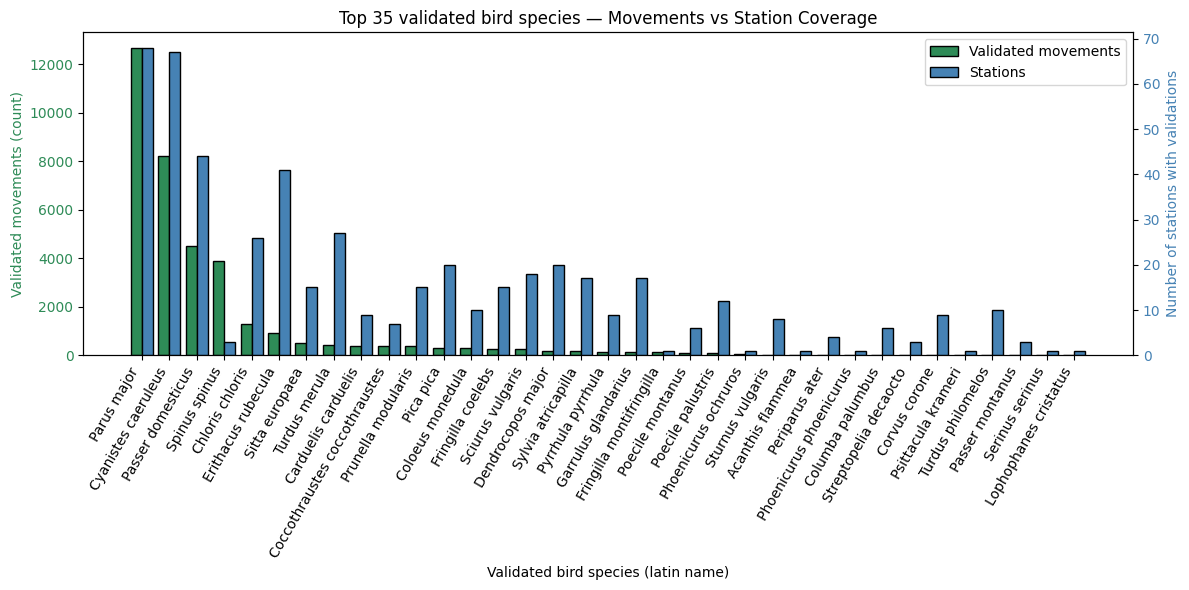

|    | latinName                     |   stationCount |   movementCount |
|---:|:------------------------------|---------------:|----------------:|
|  0 | Parus major                   |             68 |           12680 |
|  2 | Cyanistes caeruleus           |             67 |            8226 |
|  1 | Passer domesticus             |             44 |            4514 |
| 23 | Spinus spinus                 |              3 |            3884 |
| 11 | Chloris chloris               |             26 |            1295 |
|  3 | Erithacus rubecula            |             41 |             917 |
| 17 | Sitta europaea                |             15 |             504 |
|  5 | Turdus merula                 |             27 |             444 |
| 19 | Carduelis carduelis           |              9 |             401 |
|  4 | Coccothraustes coccothraustes |              7 |             392 |
| 14 | Prunella modularis            |             15 |             385 |
| 15 | Pica pica                     |

In [ ]:

from collections import defaultdict

# Define exclusion criteria
EXCLUDED_SPECIES = {"no bird", "none", "", "homo sapiens", "kohlmeise", "parus", "blau", "dole", "human", "maus"}
EXCLUDED_SUBSTRINGS = {"und", "meise", "fink", "bunt", "familie"}

species_to_stations = defaultdict(set)
species_to_movements = defaultdict(int)

for _, row in merged.iterrows():
    station_id = row["station_id"]
    validated = row.get("validatedBirds", "")
    if not isinstance(validated, str):
        continue

    matches = re.findall(r"\(([^,]+),\s*([0-9]+)\)", validated)
    for latin_name, count_str in matches:
        latin_name = latin_name.strip()
        latin_lower = latin_name.lower()

        if (
            latin_lower in EXCLUDED_SPECIES
            or any(substr in latin_lower for substr in EXCLUDED_SUBSTRINGS)
        ):
            continue

        key = latin_lower.capitalize()
        species_to_stations[key].add(station_id)
        species_to_movements[key] += int(count_str)

# Build DataFrame
rows = [
    (sp, len(stations), species_to_movements[sp])
    for sp, stations in species_to_stations.items()
]
species_df = (
    pd.DataFrame(rows, columns=["latinName", "stationCount", "movementCount"])
    .sort_values("movementCount", ascending=False)
)

# Select top-k
top_k = 35
top_species = species_df.head(top_k)

# Dual-axis plot (flipped axes)
x = np.arange(len(top_species))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: movement counts
bars1 = ax1.bar(
    x - width / 2,
    top_species["movementCount"],
    width,
    color="#2E8B57",
    edgecolor="black",
    label="Validated movements",
)

ax1.set_ylabel("Validated movements (count)", color="#2E8B57")
ax1.tick_params(axis="y", labelcolor="#2E8B57")

# Right axis: station counts
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    top_species["stationCount"],
    width,
    color="#4682B4",
    edgecolor="black",
    label="Stations",
)
ax2.set_ylabel("Number of stations with validations", color="#4682B4")
ax2.tick_params(axis="y", labelcolor="#4682B4")

# Shared labels and layout
ax1.set_xticks(x)
ax1.set_xticklabels(top_species["latinName"], rotation=60, ha="right")
ax1.set_xlabel("Validated bird species (latin name)")
ax1.set_title(f"Top {top_k} validated bird species — Movements vs Station Coverage")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

print(top_species.to_markdown())


In [44]:
from pathlib import Path
from collections import defaultdict

dataset_root = Path("./v5/dataset")

def is_image(path: Path) -> bool:
    return path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def count_images_in_split(split_dir: Path) -> dict:
    """
    Returns dict[class_name] = count_of_images for a given split directory.
    Expects structure: split_dir/class_name/*.ext
    """
    counts = defaultdict(int)
    if not split_dir.exists():
        return counts

    for class_dir in sorted(d for d in split_dir.iterdir() if d.is_dir()):
        class_name = class_dir.name
        count = sum(1 for p in class_dir.rglob("*") if p.is_file() and is_image(p))
        counts[class_name] = count

    return counts


splits = ["train", "val", "test"]
split_counts = {}

# Count images for each split
for split in splits:
    split_dir = dataset_root / split
    split_counts[split] = count_images_in_split(split_dir)

# Collect all class names across splits
all_classes = set()
for cdict in split_counts.values():
    all_classes.update(cdict.keys())
all_classes = sorted(all_classes)

print(f"Dataset root: {dataset_root}\n")
print("Per-class image counts and relative split (expected ~70/20/10):\n")

header = (
    f"{'Class':30s} "
    f"{'train':>8s} {'val':>8s} {'test':>8s} "
    f"{'train%':>8s} {'val%':>8s} {'test%':>8s}"
)
print(header)
print("-" * len(header))

for cls in all_classes:
    train_n = split_counts["train"].get(cls, 0)
    val_n   = split_counts["val"].get(cls, 0)
    test_n  = split_counts["test"].get(cls, 0)
    total   = train_n + val_n + test_n

    if total > 0:
        train_pct = 100.0 * train_n / total
        val_pct   = 100.0 * val_n / total
        test_pct  = 100.0 * test_n / total
    else:
        train_pct = val_pct = test_pct = 0.0

    print(
        f"{cls:30s} "
        f"{train_n:8d} {val_n:8d} {test_n:8d} "
        f"{train_pct:7.2f}% {val_pct:7.2f}% {test_pct:7.2f}%"
    )

# Overall counts
print("\nOverall split (all classes combined):")
total_train = sum(split_counts["train"].values())
total_val   = sum(split_counts["val"].values())
total_test  = sum(split_counts["test"].values())
grand_total = total_train + total_val + total_test

if grand_total > 0:
    train_pct = 100.0 * total_train / grand_total
    val_pct   = 100.0 * total_val / grand_total
    test_pct  = 100.0 * total_test / grand_total
else:
    train_pct = val_pct = test_pct = 0.0

print(f"train: {total_train:6d} ({train_pct:5.2f}%)")
print(f"val:   {total_val:6d} ({val_pct:5.2f}%)")
print(f"test:  {total_test:6d} ({test_pct:5.2f}%)")



Dataset root: v5\dataset

Per-class image counts and relative split (expected ~70/20/10):

Class                             train      val     test   train%     val%    test%
------------------------------------------------------------------------------------
background                         5638     1618     1029   68.05%   19.53%   12.42%
carduelis_carduelis                1669      511      293   67.49%   20.66%   11.85%
chloris_chloris                    2869      766      490   69.55%   18.57%   11.88%
coccothraustes_coccothraustes      1557      421      199   71.52%   19.34%    9.14%
cyanistes_caeruleus                2482      674      212   73.69%   20.01%    6.29%
dendrocopos_major                  1197      325      173   70.62%   19.17%   10.21%
erithacus_rubecula                 2042      606      288   69.55%   20.64%    9.81%
fringilla_coelebs                  1454      447      181   69.84%   21.47%    8.69%
garrulus_glandarius                1485      432      211  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

classes = [
    "background",
    "carduelis_carduelis",
    "chloris_chloris",
    "coccothraustes_coccothraustes",
    "cyanistes_caeruleus",
    "dendrocopos_major",
    "erithacus_rubecula",
    "fringilla_coelebs",
    "garrulus_glandarius",
    "homo_sapiens",
    "parus_major",
    "passer_domesticus",
    "poecile_palustris",
    "prunella_modularis",
    "pyrrhula_pyrrhula",
    "sitta_europaea",
    "sturnus_vulgaris",
    "turdus_merula",
]

# cm = np.array([ # SqueezeNet
#     [30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,3,26,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
#     [0,2,4,20,0,0,2,1,0,0,0,1,0,0,0,0,0,0],
#     [0,0,0,0,29,0,0,0,0,0,2,0,0,0,0,0,0,0],
#     [0,6,0,0,1,18,0,0,0,0,2,1,0,0,0,1,0,1],
#     [0,1,3,0,0,0,25,1,0,0,0,0,0,0,0,0,0,0],
#     [0,1,3,0,0,1,0,25,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,27,0,0,2,0,0,0,1,0,0],
#     [7,1,2,0,0,0,0,0,0,18,1,1,0,0,0,0,0,0],
#     [0,5,0,0,8,0,0,0,0,0,16,0,1,0,0,0,0,0],
#     [0,0,3,0,0,0,1,0,0,0,0,25,0,1,0,0,0,0],
#     [0,0,0,0,8,0,0,0,0,0,8,3,11,0,0,0,0,0],
#     [0,0,3,0,0,0,0,0,0,0,0,4,0,23,0,0,0,0],
#     [0,0,1,0,0,0,1,0,0,0,4,0,1,0,23,0,0,0],
#     [0,0,0,0,3,1,0,0,0,0,3,0,0,0,0,23,0,0],
#     [3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,20,6],
#     [0,1,1,0,0,0,0,0,0,0,1,2,0,0,0,0,0,25],
# ])

cm = np.array([    # Mobilenetv2
    [30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 29, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 6, 21, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [3, 0, 0, 0, 25, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 2, 19, 0, 0, 0, 0, 4, 0, 0, 0, 0, 3, 0, 0],
    [0, 0, 0, 0, 0, 0, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 4, 0, 0, 0, 1, 23, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 28, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [6, 2, 1, 0, 0, 0, 0, 0, 0, 21, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 28, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 20, 0, 0, 0, 0, 0, 5],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 10, 1, 16, 0, 0, 1, 0, 0],
    [0, 0, 2, 0, 0, 0, 1, 3, 0, 0, 0, 6, 0, 18, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 3, 0, 0, 0, 1, 0, 1, 0, 23, 0, 0, 1],
    [0, 0, 2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 25, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 22, 5],
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 26],
])



plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("S3_inf_confusion_matrix_mobilenetv2.png")
plt.close()
